# Getting Shape Files by Name

In [2]:
import osmnx as ox
import geopandas as gpd

In [4]:
# Specify the name that is used to seach for the data
place_name = "Edgewood Washington, DC, USA"

In [6]:
area = ox.geocode_to_gdf(place_name)

<Axes: >

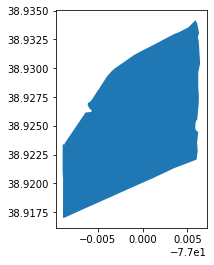

In [8]:
area.plot()

# OSM Building Footprints

In [12]:
# List key-value pairs for tags
tags = {"building": True}

buildings = ox.features_from_place(place_name, tags)
buildings.head()

addr:state amenity building  ele gnis:county_id  \
element_type osmid                                                       
node         358955022         DC  school      yes   60            001   
             367143640         DC     NaN      yes   56            NaN   
way          52291432         NaN     NaN      yes  NaN            NaN   
             55321503         NaN     NaN      yes  NaN            NaN   
             55321504          DC     NaN    house  NaN            NaN   

                            gnis:county_name gnis:created gnis:edited  \
element_type osmid                                                      
node         358955022  District of Columbia   12/18/1979  01/22/2008   
             367143640  District of Columbia          NaN         NaN   
way          52291432                    NaN          NaN         NaN   
             55321503                    NaN          NaN         NaN   
             55321504                    NaN          NaN         NaN   

                       gnis:feature_id                      gnis:import_uuid  \
element_type osmid                                                             
node         358955022         2062869  57871b70-0100-4405-bb30-88b2e001a944   
             367143640         2110453  57871b70-0100-4405-bb30-88b2e001a944   
way          52291432              NaN                                   NaN   
             55321503              NaN                                   NaN   
             55321504              NaN                                   NaN   

                        ... construction:building drive_in open_air operator  \
element_type osmid      ...                                                    
node         358955022  ...                   NaN      NaN      NaN      NaN   
             367143640  ...                   NaN      NaN      NaN      NaN   
way          52291432   ...                   NaN      NaN      NaN      NaN   
             55321503   ...                   NaN      NaN      NaN      NaN   
             55321504   ...                   NaN      NaN      NaN      NaN   

                       screen roof:shape shelter_type start_date ways type  
element_type osmid                                                          
node         358955022    NaN        NaN          NaN        NaN  NaN  NaN  
             367143640    NaN        NaN          NaN        NaN  NaN  NaN  
way          52291432     NaN        NaN          NaN        NaN  NaN  NaN  
             55321503     NaN        NaN          NaN        NaN  NaN  NaN  
             55321504     NaN        NaN          NaN        NaN  NaN  NaN  

[5 rows x 64 columns]

C:\Users\dane.parks\AppData\Roaming\Python\Python310\site-packages\ipykernel\ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


<Axes: >

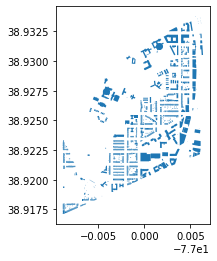

In [13]:
# Plot footprints
buildings.plot()

# Plot a Road Network

In [10]:
import osmnx as ox
import matplotlib.pyplot as plt

Fetching graph data for Columbus, Ohio...
✅ Graph data fetched.
Generating plot...


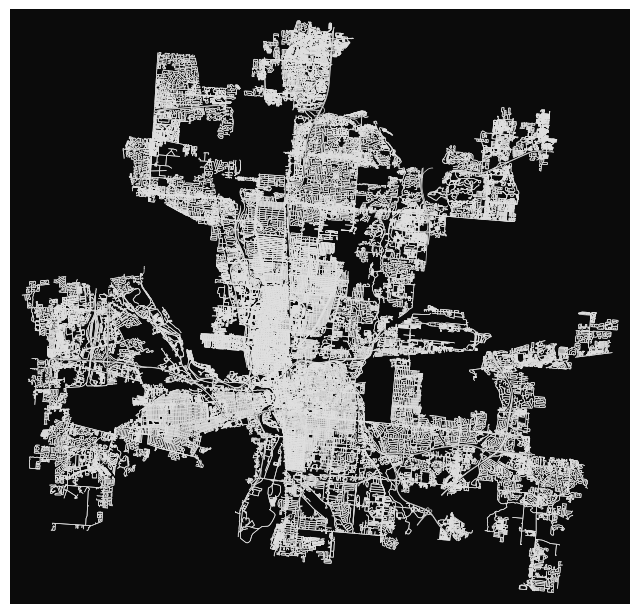

In [21]:
# 1. Get the road network graph for Columbus, Ohio
# This downloads the data from OpenStreetMap. Using network_type="all"
# gets all types of roads, not just driveable ones.
place_name = "Columbus, Ohio"
print(f"Fetching graph data for {place_name}...")
graph = ox.graph_from_place(place_name, network_type="all")
print("✅ Graph data fetched.")

# 2. Project the graph to a local UTM zone
# This is a crucial step that converts lat-long coordinates to meters,
# allowing for accurate plotting without distortion.
graph_proj = ox.project_graph(graph)

# 3. Define aesthetic properties for the plot
# You can customize these colors to your liking. A dark theme often looks
# very striking for road networks.
bg_color = "#0B0B0B"       # A very dark grey for the background
edge_color = "#E0E0E0"     # A light grey for the roads
edge_linewidth = 0.5       # Thickness of the road lines
node_size = 0              # We set this to 0 to hide the intersection dots for a cleaner look

# 4. Plot the graph to get the Matplotlib figure and axis objects
# We set `show=False` and `close=False` so we can continue to work with
# the figure before saving it.
print("Generating plot...")
fig, ax = ox.plot_graph(
    graph_proj,
    show=False,
    close=False,
    bgcolor=bg_color,
    node_size=node_size,
    edge_color=edge_color,
    edge_linewidth=edge_linewidth,
)

# 5. Set the output file properties for a high-quality print
# The map has its own natural aspect ratio. To avoid stretching it, we'll
# set the desired height (11 inches) and calculate the width to match.
dpi = 600  # High resolution for printing (dots per inch)
fig_height_in = 11  # Desired height in inches

In [22]:
# Calculate the correct width in inches to maintain the aspect ratio
x_min, x_max = ax.get_xlim()
y_min, y_max = ax.get_ylim()
aspect_ratio = (x_max - x_min) / (y_max - y_min)
fig_width_in = fig_height_in * aspect_ratio

# Apply the new figure size
fig.set_size_inches(fig_width_in, fig_height_in)

# 6. Save the final image to a file
# We use `savefig` directly on the figure object for more control.
# `bbox_inches='tight'` crops the output to the map boundaries.
file_name = place_name.replace(', ', '_')
filepath = f"{file_name}_Roads_Styled.png"
print(f"Saving high-resolution plot to {filepath}...")
fig.savefig(
    filepath,
    dpi=dpi,
    format="png",
    bbox_inches="tight",
    pad_inches=0,
    facecolor=bg_color
)
plt.close(fig) # Close the plot to free memory

print(f"✅ Successfully saved the image.")

Saving high-resolution plot to Columbus_Ohio_Roads_Styled.png...
✅ Successfully saved the image.


# Ohio Specific Data

In [31]:
import requests
import json
import pandas as pd

# The Overpass API endpoint
overpass_url = "https://overpass-api.de/api/interpreter"

# The Overpass QL query to find various linear features within the state of Ohio.
# It looks for relations (like numbered routes) and ways (like individual rivers/tracks).
overpass_query = """
[out:json][timeout:180];
area["ISO3166-2"="US-OH"]->.ohio;
(
  // Numbered Road Routes (as relations)
  relation["type"="route"]["route"="road"](area.ohio);
  
  // Numbered Bicycle Routes (as relations)
  relation["type"="route"]["route"="bicycle"](area.ohio);
  
  // Rivers (as ways)
  way["waterway"="river"](area.ohio);
  
  // Railways (as ways)
  way["railway"~"rail|light_rail"](area.ohio);
  
  // Major paths and cycleways (as ways)
  way["highway"~"cycleway|path|footway|track"](area.ohio);
);
out tags;
"""

print("🛰️  Querying the OpenStreetMap Overpass API for Ohio linear features...")

try:
    # Make the POST request to the API
    response = requests.post(overpass_url, data=overpass_query)
    response.raise_for_status()  # Raise an exception for bad status codes (4xx or 5xx)

    # Parse the JSON response
    data = response.json()

    # We will store the full data for each feature in a list of dictionaries
    features_data = data.get('elements', [])

    # Define a sort key that attempts to sort numerically by the 'ref' tag.
    # This ensures that '2' comes before '10'. Non-numeric refs are placed at the end.
    def sort_key(element):
        ref = element.get('tags', {}).get('ref', '').split(';')[0]
        try:
            return int(ref)
        except (ValueError, TypeError):
            return float('inf') # Push non-integer refs to the bottom

    features_data.sort(key=sort_key)

    print(f"\n✅ Found {len(features_data)} features in Ohio. Displaying as a DataFrame:")
    
    # Extract just the 'tags' dictionary from each element for the DataFrame
    tags_list = [feature['tags'] for feature in features_data]
    df = pd.DataFrame(tags_list)

    # Define the columns we are most interested in displaying.
    preferred_order = ['ref', 'name', 'network', 'route', 'highway', 'railway', 'waterway', 'bridge', 'type', 'service']
    
    # Find which of our preferred columns actually exist in the DataFrame.
    existing_cols = [col for col in preferred_order if col in df.columns]
    
    # Filter the DataFrame to show only these existing, preferred columns.
    df = df[existing_cols]

    # Replace NaN values with empty strings for a cleaner display
    df.fillna('', inplace=True)

    # Set pandas display options to show all rows and columns without truncation
    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 120)

    # Print the final DataFrame
    # print(df)


except requests.exceptions.RequestException as e:
    print(f"❌ An error occurred: {e}")
except json.JSONDecodeError:
    print("❌ Failed to decode the response from the server. The server may be overloaded.")

🛰️  Querying the OpenStreetMap Overpass API for Ohio linear features...

✅ Found 401892 features in Ohio. Displaying as a DataFrame:


In [32]:
df['route'].unique()

array(['', 'road', 'bicycle', 'mtb', 'fitness_trail', 'hiking', 'foot'],
      dtype=object)

# Plot a Rail Network

[OpenRailMap.org](https://www.openrailwaymap.org/)

[OpenRailMap API (expirimental)](https://github.com/OpenRailwayMap/OpenRailwayMap-api)

[OpenRailMap Application](https://github.com/OpenRailwayMap/OpenRailwayMap)

[North America Tagging Rules](https://wiki.openstreetmap.org/wiki/OpenRailwayMap/Tagging_in_North_America)

## Basic API Request

In [40]:
import requests

# openrailwaymap blocks python but allows traffic from browsers, so set a header
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/56.0.2924.76 Safari/537.36"
}
response = requests.get(
    "https://api.openrailwaymap.org/v2/facility?name=Karlsruhe&limit=1", headers=headers
)

# Printing the response text
data = response.json()[0]

In [41]:
data

{'osm_id': 2574283615,
 'name': 'Karlsruhe Hauptbahnhof',
 'railway': 'station',
 'ref': None,
 'iata': 'KJR',
 'uic_ref': '8000191',
 'website': 'https://www.bahnhof.de/bahnhof-de/bahnhof/Karlsruhe-Hbf-1019530',
 'operator': 'DB Station&Service AG',
 'wikidata': 'Q688541',
 'iata:note': 'AIRail Flughafen',
 'max_level': '1',
 'min_level': '-1',
 'platforms': '7',
 'ref:IFOPT': 'de:08212:90',
 'wikipedia': 'de:Karlsruhe Hauptbahnhof',
 'short_name': 'Karlsruhe Hbf',
 'wheelchair': 'yes',
 'railway:ref': 'RK',
 'ref:station': '3107',
 'internet_access': 'wlan',
 'public_transport': 'station',
 'internet_access:fee': 'no',
 'internet_access:ssid': 'Telekom',
 'internet_access:operator': 'Deutsche Telekom AG',
 'railway:station_category': '1',
 'internet_access:fee:description': '30min kostenlos',
 'latitude': 8.4020518,
 'longitude': 48.9936163996939,
 'rank': 176}